## Alchemy


In [1]:
# Jupyter cell: Initialize and optimize SQLite in FLY

# 1) Imports
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker

from infrastructure.config import Config

In [1]:
# 2) Load application configuration
#    Adjust constructor as needed (e.g., passing path to config file or env vars)
config = Config()

NameError: name 'Config' is not defined

In [ ]:
# 3) Create the SQLAlchemy engine with thread-safe and future settings
engine = create_engine(
    config.database.connection_string,
    connect_args={"check_same_thread": False},  # allow multi-thread access
    future=True,
)

In [ ]:
# 4) Execute SQLite PRAGMAs for performance & integrity
with engine.connect() as conn:  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint"))  # type: ignore

    # ou, se preferir garantir que todo o WAL seja aplicado e truncado:
    conn.execute(text("PRAGMA wal_checkpoint(FULL)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(RESTART)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(TRUNCATE)"))  # type: ignore
    conn.execute(text("PRAGMA optimize"))  # type: ignore # Run internal optimizations
    conn.execute(text("PRAGMA journal_mode=WAL"))  # type: ignore # Write-Ahead Logging
    conn.execute(text("PRAGMA synchronous=FULL"))  # type: ignore # Full disk sync for safety
    conn.execute(text("PRAGMA foreign_keys=ON"))  # type: ignore # Enforce FK constraints
    conn.execute(text("PRAGMA temp_store=MEMORY"))  # type: ignore # RAM for temp tables
    conn.execute(text("PRAGMA cache_size=-65536"))  # type: ignore # 64 MB cache

In [ ]:
# 5) Create a session factory for ORM transactions
Session = sessionmaker(  # type: ignore
    bind=engine,  # type: ignore
    autoflush=True,
    expire_on_commit=True,
)

In [ ]:
# 6) (Optional) Inspect existing tables
with Session() as session:  # type: ignore
    result = session.execute(text("SELECT name FROM sqlite_master WHERE type='table';"))  # type: ignore
    tables = [row[0] for row in result]
    print("⏺️ Tables in database:", tables)

## YFINANCE

In [1]:
import yfinance as yf

tickers = ["LREN3.SA", "VALE3.SA"]

# Histórico diário
df = yf.download(tickers, start="1960-01-01", interval="1d",)


C:\Users\faust\AppData\Local\Temp\ipykernel_22404\3791307439.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="1960-01-01", interval="1d",)
[*********************100%***********************]  2 of 2 completed


In [2]:
df

Price             Close                    High                     Low  \
Ticker         LREN3.SA   VALE3.SA     LREN3.SA   VALE3.SA     LREN3.SA   
Date                                                                      
2000-01-03          NaN   1.389175          NaN   1.406043          NaN   
2000-01-04  5426.253418   1.356099  8440.839283   1.378921  5426.253418   
2000-01-05  5426.253418   1.356099  5426.253418   1.356099  5426.253418   
2000-01-06  5426.253418   1.356099  5426.253418   1.389174  5426.253418   
2000-01-07  5426.253418   1.405712  5426.253418   1.412658  5426.253418   
...                 ...        ...          ...        ...          ...   
2025-09-22    16.045443  58.000000    16.499093  58.439999    15.966547   
2025-09-23    15.700274  57.669998    16.252544  58.389999    15.611516   
2025-09-24    15.940000  57.889999    15.950000  58.139999    15.410000   
2025-09-25    15.720000  58.209999    16.170000  58.549999    15.710000   
2025-09-26    15.820000  57.090000    16.040001  57.939999    15.680000   

Price                         Open                 Volume            
Ticker       VALE3.SA     LREN3.SA   VALE3.SA    LREN3.SA  VALE3.SA  
Date                                                                 
2000-01-03   1.389175          NaN   1.389175         NaN    585600  
2000-01-04   1.356099  8440.839283   1.375944         0.0    782400  
2000-01-05   1.339561  5426.253418   1.339561         0.0   1876800  
2000-01-06   1.356099  5426.253418   1.356099         0.0    792000  
2000-01-07   1.372636  5426.253418   1.372636         0.0   5347200  
...               ...          ...        ...         ...       ...  
2025-09-22  57.810001    16.479368  57.820000  15873500.0  21947300  
2025-09-23  57.660000    16.055305  58.000000  29583700.0  17652400  
2025-09-24  57.669998    15.810000  57.950001  21931600.0  13005700  
2025-09-25  58.040001    15.890000  58.189999  17435400.0  13631100  
2025-09-26  56.540001    15.840000  57.740002  12917600.0  29037000  

[6463 rows x 10 columns]

### Preço atual e variação intraday

In [3]:
info = yf.Tickers(" ".join(tickers))

for t in tickers:
    data = info.tickers[t].info
    print(
        t,
        "Preço:", data.get("regularMarketPrice"),
        "Variação:", data.get("regularMarketChange"),
        "Variação %:", data.get("regularMarketChangePercent"),
    )


LREN3.SA Preço: 15.82 Variação: 0.09999943 Variação %: 0.63612866
VALE3.SA Preço: 57.09 Variação: -1.1199989 Variação %: -1.9240663


### Dados fundamentais

In [4]:
data = {}

for t in tickers:
    tk = yf.Ticker(t)
    info = tk.info
    data[t] = {
        "Nome": info.get("longName"),
        "Setor": info.get("sector"),
        "Indústria": info.get("industry"),
        "Valor de Mercado": info.get("marketCap"),
        "P/L": info.get("trailingPE"),
        "Lucro por Ação (EPS)": info.get("trailingEps"),
        "Dividend Yield": info.get("dividendYield"),
        "Beta": info.get("beta"),
        "Moeda": info.get("currency"),
    }

import pandas as pd
df = pd.DataFrame(data).T
df


,Nome,Setor,Indústria,Valor de Mercado,P/L,Lucro por Ação (EPS),Dividend Yield,Beta,Moeda
LREN3.SA,Lojas Renner S.A.,Consumer Cyclical,Department Stores,15686266880,12.076336,1.31,5.56,0.593,BRL
VALE3.SA,Vale S.A.,Basic Materials,Other Industrial Metals & Mining,243704578048,8.71603,6.55,11.65,1.039,BRL


In [5]:

t = yf.Ticker("VAle3.SA")

# Retorna todos os campos de fundamentos
info = t.info

# Converter para DataFrame para melhor leitura
df = pd.DataFrame(info.items(), columns=["Campo", "Valor"])
df

,Campo,Valor
0,address1,Praia de Botafogo
1,address2,"186 offices 1101, 1701, and 1801 Botafogo"
2,city,Rio De Janeiro
3,state,RJ
4,zip,22250-145
...,...,...
160,sourceInterval,15
161,exchangeDataDelayedBy,15
162,averageAnalystRating,2.1 - Buy
163,cryptoTradeable,False


### Dados financeiros estruturados

In [6]:
import yfinance as yf

tickers = ["LREN3.SA"]

for t in tickers:
    tk = yf.Ticker(t)

    print(f"\n--- {t} ---")

    # Demonstrativos de resultado (anual e trimestral)
    print("Income Statement (anual):")
    print(tk.financials)

    print("\nIncome Statement (trimestral):")
    print(tk.quarterly_financials)

    # Balanço patrimonial
    print("\nBalance Sheet (anual):")
    print(tk.balance_sheet)

    print("\nBalance Sheet (trimestral):")
    print(tk.quarterly_balance_sheet)

    # Fluxo de caixa
    print("\nCashflow (anual):")
    print(tk.cashflow)

    print("\nCashflow (trimestral):")
    print(tk.quarterly_cashflow)



--- LREN3.SA ---
Income Statement (anual):
                                                      2024-12-31  \
Tax Effect Of Unusual Items                        -1.025383e+08   
Tax Rate For Calcs                                  9.410000e-02   
Normalized EBITDA                                   3.972445e+09   
Total Unusual Items                                -1.089674e+09   
Total Unusual Items Excluding Goodwill             -1.089674e+09   
Net Income From Continuing Operation Net Minori...  1.196668e+09   
Reconciled Depreciation                             1.244254e+09   
Reconciled Cost Of Revenue                          5.694417e+09   
EBITDA                                              2.882771e+09   
EBIT                                                1.638517e+09   
Net Interest Income                                -5.202990e+08   
Interest Expense                                    3.175200e+08   
Interest Income                                     3.124010e+08   
Norm

In [7]:
tk.eps_revisions

,upLast7days,upLast30days,downLast30days,downLast7Days
period,,,,
0q,0,0,0,0
+1q,0,1,1,0
0y,1,3,4,0
+1y,1,2,5,3


## BCB Series

In [583]:
import requests
from bs4 import BeautifulSoup
import time
import csv
import os
import re

In [584]:
# --- FILE NAMES
csv_file_name = 'bcb_series_completas.csv'
csv_headers = [
        'Codigo', 'Nome_Completo', 'Unidade', 'Periodicidade', 'Data_Inicio', 'Ultimo_Valor', 'Fonte'
    ]

# --- URLs de Ação (Sequência Mínima) ---
BASE_URL = "https://www3.bcb.gov.br/sgspub"
SEARCH_POST_URL = f"{BASE_URL}/localizarseries/localizarSeries.paint?method=localizarSeriesPorPesquisaAvancada"
PAGINATION_URL = f"{BASE_URL}/localizarseries/localizarSeries.do?method=getPagina"

METADATA_URL = f'{BASE_URL}/localizarseries/localizarSeries.do?method=recuperarMetadadosPorDocn'
METADADOS_BASICOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiDadosBasicos.jsp'
METADADOS_COMPLETOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiMetadados.jsp'

# --- HEADERS ---
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
    'Content-Type': 'application/x-www-form-urlencoded',
}

# --- PAYLOADS ---
INITIAL_PAYLOAD = {
    'codigos': '', 'periodicidade': '0', 'fonte': '0', 'unidadePadrao': '0',
    'filtro': '0', 'chkClassificacao': 'on', 'txtPesquisa': '', 'ordem1': '0',
    'sentido1': '0', 'ordem2': '0', 'sentido2': '0', 'ordem3': '0',
    'sentido3': '0', 'hdCodigos': '', 'hdGrupos': '', 'hdTipoPesquisa': '9',
    'hdTipoOrdenacao': '0', 'hdPeriodicidade': 'Todas', 'hdFonte': 'Todas',
    'hdUnidadePadrao': 'Todas', 'hdFiltro': ''
}
BASE_PAYLOAD_PAGINATION = {
    'periodicidade': '0', 'codigo': '', 'fonte': '341', 'texto': '',
    'hdFiltro': '', 'hdOidGrupoSelecionado': '', 'hdSeqGrupoSelecionado': '',
    'hdNomeGrupoSelecionado': '', 'hdTipoPesquisa': '9', 'hdTipoOrdenacao': '0',
    'hdPeriodicidade': 'Todas', 'hdSeriesMarcadas': '', 'hdMarcarTodos': '',
    'hdFonte': '', 'hdOidSerieMetadados': '', 'hdNumeracao': '',
    'hdOidSeriesLocalizadas': '',
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
METADATA_PAYLOAD_BASE = { 
    # ... (Campos do seu payload de metadados aqui) ...
    'hdOidSerieMetadados': '', # OBRIGATÓRIO: Código da Série
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
HEADERS_TO_IGNORE = ["Sumário Metodológico", "Formatos de Divulgação", "Summary Methodology", "Dissemination Formats", ]


In [585]:
def clean_cell(text):
    if not isinstance(text, str):
        return text

    text = text.replace('\x96', '–').replace('\x93', '"').replace('\x94', '"')
    text = text.replace('\xa0', ' ') # Remove Non-breaking space
    text = text.replace('*', '') # <--- REMOVE O ASTERISCO DE QUALQUER CHAVE OU VALOR

    # 2. Regex: Substitui qualquer sequência de whitespace por um único espaço
    text= re.sub(r'\s+', ' ', text).strip()

    return text


In [614]:
def save_to_csv(data_list, csv_file_name):
    if not data_list:
        print("Nenhum dado para salvar em CSV.")
        return

    csv_headers = []

    # 2. Set para garantir a unicidade e rapidez na checagem
    seen_fields = set()

    # Itera sobre cada dicionário de metadados
    for series_dict in data_list:
        # Itera sobre as chaves do dicionário (a ordem de iteração é importante)
        for field in series_dict.keys():
            if field not in seen_fields:
                # Adiciona à lista de cabeçalhos e ao set de controle
                csv_headers.append(field)
                seen_fields.add(field)

    try:
        with open(csv_file_name, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=csv_headers)

            writer.writeheader()
            writer.writerows(data_list)

        print(f"Total de {len(data_list)} séries salvas em '{csv_file_name}'.")

    except Exception as e:
        print(f"ERRO ao salvar o arquivo CSV: {e}")

In [615]:
def parse_page_data(html_content):
    """Extrai os dados da tabela HTML, retornando uma lista de dicionários."""
    soup = BeautifulSoup(html_content, 'html.parser')

    table = soup.find('table', id='tabelaSeries')
    if not table:
        return []

    series_data = []

    # Busca todas as linhas (<tr>) diretamente na <table>.
    all_rows = table.find_all('tr')

    for row in all_rows:
        cells = row.find_all('td', recursive=False)

        # Ignora linhas de cabeçalho e linhas incompletas.
        if len(cells) < 10:
            continue

        # Mapeamento dos dados
        data = {
            'Codigo': clean_cell(cells[1].text),
            'Nome_Completo': clean_cell(cells[2].text),
            'Unidade': clean_cell(cells[3].text),
            'Periodicidade': clean_cell(cells[4].text),
            'Data_Inicio': clean_cell(cells[5].text),
            'Ultimo_Valor': clean_cell(cells[6].text),
            'Fonte': clean_cell(cells[7].text),
        }
        series_data.append(data)

    return series_data

In [587]:
def fetch_series(series, soup_basico, metadata_completo):
    metadata = {}
    metadata_basico = soup_basico.find_all('table')
    for t, table in enumerate(metadata_basico):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            # Buscar células de dados (<td>)
            cells = row.find_all('td')
            # Assume a estrutura de 4 colunas (Rótulo, Valor, Rótulo, Valor)
            for i in range(0, len(cells), 2):
                if i + 1 < len(cells):
                    label = clean_cell(cells[i].text)
                    value = clean_cell(cells[i+1].text)
                    if label:
                        metadata[label] = value

    last_cell = None
    for t, table in enumerate(metadata_completo):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            cells = row.find_all('td')
            cell_count = len(cells)
            if cell_count > 2:
                continue
            elif cell_count == 2:
                # Condição: Rótulo e Valor na mesma linha (Estrutura 2-col)
                # O bloco anterior de iteração foi removido
                label = clean_cell(cells[0].text)
                value = clean_cell(cells[1].text)

                if label and label not in HEADERS_TO_IGNORE:
                    metadata[label] = value

                # Zera o last_cell, pois um par K:V completo foi encontrado
                last_cell = None 

            elif cell_count == 1:
                # Condição: Máquina de Estados para conteúdo multi-linha (Estrutura 1-col)
                content = clean_cell(cells[0].text)

                # 1. Se existe uma chave pendente (last_cell):
                if last_cell:
                    # O 'content' atual é o VALOR para a chave pendente.
                    # Se o conteúdo estiver vazio, armazena vazio. Se tiver texto longo, armazena o texto limpo.
                    metadata[last_cell] = content
                    # Zera o estado após encontrar o valor
                    last_cell = None 

                # 2. Se NÃO existe chave pendente e o 'content' é um rótulo válido:
                elif content and content not in HEADERS_TO_IGNORE:
                    # O 'content' é um novo rótulo (chave) que espera um valor na próxima linha
                    last_cell = content
    series.update(metadata)

    return series


In [618]:
def scrape_all_series():
    """Executa o scraping completo e retorna a lista de dicionários de séries."""
    all_data = []
    session = requests.Session()
    max_retries = 3

    # --- 1. ESTABELECIMENTO DE SESSÃO ---
    response_session = session.get(BASE_URL)
    response_initial = session.post(SEARCH_POST_URL, data=INITIAL_PAYLOAD, headers=HEADERS, timeout=30)

    # --- 2. LOOP DE PAGINAÇÃO ---
    page_num = 1
    previous_content_hash = hash(response_initial.text)
    previous_content_hash = hash(response_session.text)

    while True:
        current_payload = BASE_PAYLOAD_PAGINATION.copy()
        current_payload['hdNumPagina'] = str(page_num)

        retries = 0
        current_html = ""

        # Tenta o request de paginação
        while retries < max_retries:
            try:
                response_page = session.post(PAGINATION_URL, data=current_payload, headers=HEADERS, timeout=10)
                response_page.raise_for_status() 
                current_html = response_page.text
                break
            except requests.exceptions.RequestException:
                retries += 1
                time.sleep(3)

        if retries == max_retries:
            print(f"Falha na página {page_num}. Abortando.")
            break

        # Verifica se o conteúdo é o mesmo da página anterior (indicador de fim)
        current_content_hash = hash(current_html.replace('\r\n', ''))
        if current_content_hash == previous_content_hash:
            print(f"Conteúdo da página {page_num} idêntico. Fim da paginação.")
            break

        previous_content_hash = current_content_hash

        data_page = parse_page_data(current_html)

        if not data_page:
            print(f"Página {page_num} não retornou linhas. Encerrando.")
            break

        series_data = []
        for s, series in enumerate(data_page):
            payload = METADATA_PAYLOAD_BASE.copy()
            codigo = series['Codigo'] # Inserindo o código dinamicamente
            fonte = series['Fonte']
            nome = series['Nome_Completo']
            payload['hdOidSerieMetadados'] = codigo

            print(f"Página {page_num}-{(len(all_data)+s)} {codigo}-{fonte}-{nome}")
            session.post(METADATA_URL, data=payload, headers=HEADERS, timeout=10)
            response_basico = session.get(METADADOS_BASICOS_URL, headers=HEADERS, timeout=10)
            soup_basico = BeautifulSoup(response_basico.text, 'html.parser')

            response_completo = session.get(METADADOS_COMPLETOS_URL, headers=HEADERS, timeout=10)
            soup_completo = BeautifulSoup(response_completo.text, 'html.parser')
            metadata_completo = soup_completo.find_all('table')

            updated_series = fetch_series(series, soup_basico, metadata_completo)
            series_data.append(updated_series) # Usa append() para adicionar o dicionário)

        all_data.extend(series_data)
        if all_data is not None:
            save_to_csv(all_data, csv_file_name)
            print(f"Página {page_num} capturada. Total geral: {len(all_data)}")
        else:
            print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

        page_num += 1
        # time.sleep(0.3)

    print("\nColeta finalizada.")
    return all_data

In [ ]:
# 1. Executa o scraping e armazena o resultado
bcb_series = scrape_all_series()

# 2. Salva a lista em CSV
if bcb_series is not None:
    save_to_csv(bcb_series, csv_file_name)
else:
    print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

## SQLITE


In [9]:
import sqlite3
import pandas as pd
import matplotlib 

In [2]:
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db"
raw = "tbl_statements_raw"
fetched = "tbl_statements_fetched"
stock_quote = "tbl_stock_quote"

In [3]:
# conecta ao banco
conn = sqlite3.connect(db_path)

# lê a tabela em um DataFrame
df = pd.read_sql(f"SELECT * FROM {stock_quote}", conn)


<Axes: >

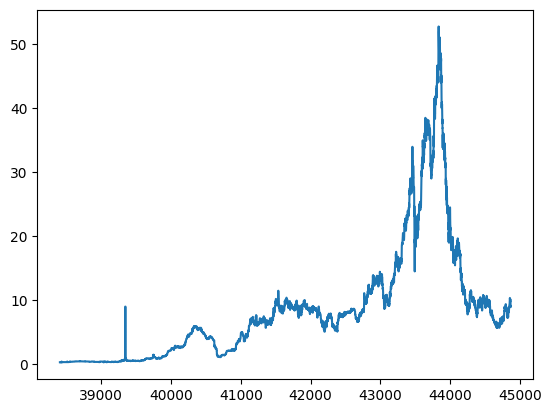

In [10]:
ticker = "ALPA3"

mask = df['ticker'] == ticker
df[mask]['close'].plot()

In [ ]:
# fecha a conexão se não precisar mais
conn.close()
